# Histogram tutorial: build → build → subset → match percentiles

This notebook walks through `python_obj`'s reflectivity-distribution ("histogram") capability -- a generalization of `python_base`'s hardcoded `mrms_dz_histogram_*.py`/`wofs_dz_histogram_*.py` scripts, used to identify object-identification thresholds that are *comparable* across sources via matched percentiles (e.g. "what MPAS reflectivity value is the same percentile as MRMS's 40 dBZ?").

Unlike the original scripts (which collapse an entire day/forecast directory into one flat histogram), this library preserves one histogram *slice* per input file -- tagged with its real `valid_time` and (for model data) `lead_hours`/`member_id` -- inside each per-day (MRMS) / per-forecast (model) output file. That's what makes the two steps below possible at all:

1. **Build** a per-day MRMS histogram and a per-forecast MPAS histogram from the bundled real sample data.
2. **Subset** each after the fact -- an hour-of-day MRMS climatology, a forecast-lead-hour ("day N") model bucket.
3. **Match percentiles** between the two full distributions -- the actual end goal.

Every step below calls the same `run_one_case(config_path)` function a standalone driver script (`python_obj/drivers/`) would call from the command line. All parameters live in `python_obj/configs/config_sample_histogram.yaml` (`histogram_observations:`/`histogram_model:` sections) -- copy it and point `CONFIG_PATH` at a different config to reuse this notebook for a different case.

In [1]:
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from python_obj.config import load_config
from python_obj.drivers import aggregate_histograms, build_histogram_mrms, build_histogram_model
from python_obj.histogram import (
    by_hour_of_day, by_lead_hours_range, histogram_to_cdf, histogram_to_pdf,
    read_histogram_file, sum_histograms,
)

CONFIG_PATH = "../configs/config_sample_histogram.yaml"

cfg = load_config(CONFIG_PATH)
print(f"histogram_observations:\n  {cfg.histogram_observations}\n")
print(f"histogram_model:\n  {cfg.histogram_model}\n")

histogram_observations:
  HistogramObservationConfig(interp_mrms_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/interp_mrms', var_name='refl_consv', lat_name='lat', lon_name='lon', output_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/hist_mrms_sample', bin_min=-20.0, bin_max=80.0, bin_width=0.2, edge_trim=7, clip_negative_to_zero=False)

histogram_model:
  HistogramModelConfig(input_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/mpas_mem1', var_name='refl10cm_max', lat_name='latitude', lon_name='longitude', member_subdirs=False, stacked_members=False, file_pattern='*_f00[1-3].nc', init_attr='initializationTime', lead_attr='forecastHour', lead_units='hours', init_format='%Y%m%d%H', valid_time_attr=None, valid_time_format=None, init_time_attr='init_time', output_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/his

## Step 1 — Build the per-day MRMS histogram

Groups `histogram_observations.interp_mrms_dir` by its `YYYYMMDD` day-subdirectories (the bundled sample has one real day, 2023-05-01, 3 hourly files) and writes **one histogram file per day**, with one slice per file (tagged with that file's real `valid_time`).

In [2]:
mrms_hist_paths = build_histogram_mrms.run_one_case(CONFIG_PATH)

for path in mrms_hist_paths:
    contents = read_histogram_file(path)
    print(f"\n{os.path.basename(path)}: {len(contents.slices)} slices")
    for s in contents.slices:
        print(f"  valid_time={s.valid_time}  total_counts={s.hist.sum()}")

Found 3 interpolated MRMS files across 1 day(s) under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/interp_mrms'
Building histograms: var_name=refl_consv, bins=[-20.0, 80.0] by 0.2, edge_trim=7, clip_negative_to_zero=False
  wrote /Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/hist_mrms_sample/hist_mrms_20230501.nc (3 slices, 167088 total counts)

hist_mrms_20230501.nc: 3 slices
  valid_time=2023-05-01 01:00:41  total_counts=55696
  valid_time=2023-05-01 02:00:38  total_counts=55696
  valid_time=2023-05-01 03:00:35  total_counts=55696


## Step 2 — Build the per-forecast MPAS histogram

Builds one manifest for the whole configured forecast (`histogram_model.input_dir`, f001-f003 in the bundled sample) via the same `python_obj.obj_core.build_model_manifest` `identify_track_model.py` itself uses, and writes **one histogram file for the whole forecast**, with one slice per lead time (tagged with real `valid_time` + `lead_hours`).

In [3]:
model_hist_path = build_histogram_model.run_one_case(CONFIG_PATH)

model_contents = read_histogram_file(model_hist_path)
print(f"\n{os.path.basename(model_hist_path)}: {len(model_contents.slices)} slices")
for s in model_contents.slices:
    print(f"  valid_time={s.valid_time}  lead_hours={s.lead_hours}  total_counts={s.hist.sum()}")

Found 3 manifest entries under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/mpas_mem1' (member_subdirs=False, stacked_members=False)
Building histogram: var_name=refl10cm_max, bins=[-20.0, 80.0] by 0.2, edge_trim=7, clip_negative_to_zero=False
  wrote /Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/hist_model_sample/hist_model_20230501_010000.nc (3 slices, 167088 total counts)

hist_model_20230501_010000.nc: 3 slices
  valid_time=2023-05-01 01:00:00  lead_hours=1.0  total_counts=55696
  valid_time=2023-05-01 02:00:00  lead_hours=2.0  total_counts=55696
  valid_time=2023-05-01 03:00:00  lead_hours=3.0  total_counts=55696


## Step 3 — Subset the output files after the fact

This is the capability the original `python_base` scripts couldn't support (their output was already collapsed to one flat histogram): rebuild a *subset* distribution straight from the per-slice output files.

- **MRMS climatology by hour of day** (`by_hour_of_day`) -- e.g. every slice valid at a given UTC hour, across as many days as you have output files for.
- **Model "day N of the forecast"** (`by_lead_hours_range`) -- e.g. lead hours 0-24 vs. 24-48 for a multi-day forecast.

In [4]:
first_hour = read_histogram_file(mrms_hist_paths[0]).slices[0].valid_time.hour
mrms_bins, mrms_full = sum_histograms(mrms_hist_paths)
_, mrms_hour_subset = sum_histograms(mrms_hist_paths, predicate=by_hour_of_day(first_hour))
print(f"MRMS full distribution: {mrms_full.sum()} counts")
print(f"MRMS subset (hour={first_hour:02d}Z climatology): {mrms_hour_subset.sum()} counts")

model_bins, model_full = sum_histograms([model_hist_path])
_, model_day1 = sum_histograms([model_hist_path], predicate=by_lead_hours_range(0.0, 24.0))
print(f"\nModel full distribution: {model_full.sum()} counts")
print(f"Model subset (lead 0-24h, 'day 1'): {model_day1.sum()} counts")

MRMS full distribution: 167088 counts
MRMS subset (hour=01Z climatology): 55696 counts

Model full distribution: 167088 counts
Model subset (lead 0-24h, 'day 1'): 167088 counts


## Step 4 — Matched-percentile threshold (the actual end goal)

The generalized port of `wofs_dz_histogram_plotter.py`'s method: find a source threshold's percentile in the source distribution, then find the target distribution's value at that same percentile. Both distributions are used exactly as built -- no bin is zeroed or excluded. Earlier versions of this library tried to dynamically locate and zero out "the bin containing 0 dBZ" as a clear-air/no-echo correction, but that assumes clear air always sits near 0 dBZ, which is source-specific (confirmed: MRMS's floor is ~0.0 dBZ, but MPAS's is exactly -35.0 dBZ) and was silently dropping any pixel outside the fixed `[-20, 80]` bin range for whichever source's floor fell outside it (MPAS's did, MRMS's didn't) -- so the two sources' total histogram counts didn't actually represent the same number of gridpoints even on an identical grid. Fixed: every valid pixel is now clamped into the nearest edge bin rather than dropped (see Step 1/2 above -- MRMS and MPAS now both report exactly 167,088 total counts on this shared grid), and clear air is included like any other value.

In [5]:
result = aggregate_histograms.run_one_case(CONFIG_PATH, source_threshold_dbz=40.0)

Found 1 MRMS histogram file(s), 1 model histogram file(s)
MRMS full distribution: 167088 total counts
Model full distribution: 167088 total counts
MRMS subset (hour=01Z climatology): 55696 counts
Model subset (lead 0-24h, 'day 1'): 167088 counts

Matched-percentile threshold: MRMS 40.0 dBZ is the 99.9th percentile of the MRMS distribution -- the model's 99.9th percentile is 41.0 dBZ


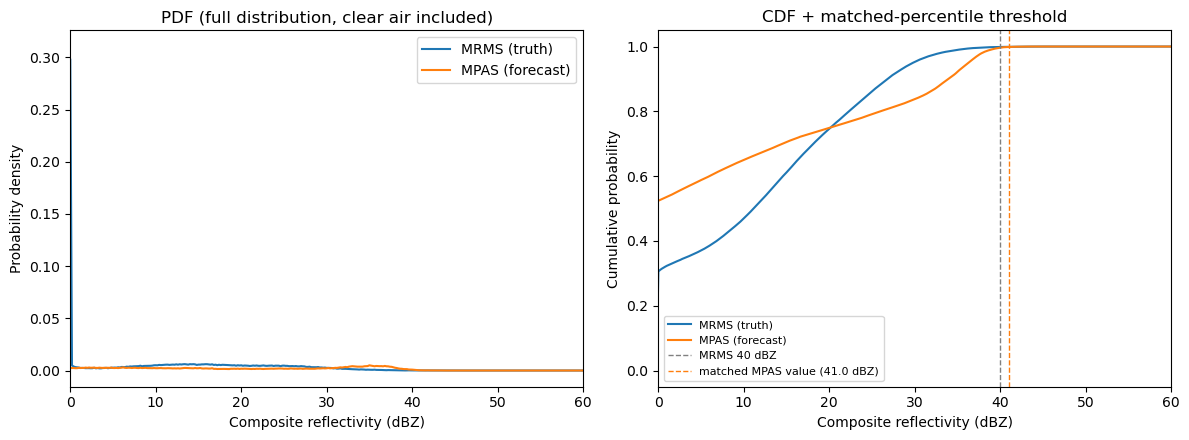

In [6]:
import matplotlib.pyplot as plt

mrms_pdf = histogram_to_pdf(mrms_bins, mrms_full)
model_pdf = histogram_to_pdf(model_bins, model_full)
mrms_cdf = histogram_to_cdf(mrms_bins, mrms_full)
model_cdf = histogram_to_cdf(model_bins, model_full)
plot_bins = mrms_bins[:-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(plot_bins, mrms_pdf, label="MRMS (truth)", color="tab:blue")
ax1.plot(plot_bins, model_pdf, label="MPAS (forecast)", color="tab:orange")
ax1.set_xlim(0, 60); ax1.set_xlabel("Composite reflectivity (dBZ)"); ax1.set_ylabel("Probability density")
ax1.set_title("PDF (full distribution, clear air included)"); ax1.legend()

ax2.plot(plot_bins, mrms_cdf, label="MRMS (truth)", color="tab:blue")
ax2.plot(plot_bins, model_cdf, label="MPAS (forecast)", color="tab:orange")
ax2.axvline(40.0, color="gray", linestyle="--", linewidth=1, label="MRMS 40 dBZ")
ax2.axvline(result["target_value"], color="tab:orange", linestyle="--", linewidth=1,
            label=f"matched MPAS value ({result['target_value']:.1f} dBZ)")
ax2.set_xlim(0, 60); ax2.set_xlabel("Composite reflectivity (dBZ)"); ax2.set_ylabel("Cumulative probability")
ax2.set_title("CDF + matched-percentile threshold"); ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Closing

This notebook built real per-day/per-forecast histograms from the bundled sample data, subset them by hour-of-day and forecast-lead-hour, and computed a real matched-percentile threshold between MRMS truth and an MPAS forecast.

To adapt this notebook to a real, larger case: copy `configs/config_sample_histogram.yaml`, point `histogram_observations.interp_mrms_dir` at a real multi-day archive of interpolated MRMS and `histogram_model.input_dir` at a real multi-day forecast, and re-run -- `by_lead_hours_range(0, 24)`/`by_lead_hours_range(24, 48)`/... then genuinely separates a 5-day forecast into daily buckets, and `by_hour_of_day` genuinely builds an N-day climatology, exactly as requested. See `python_obj/drivers/README.md` for the full config-field reference.